# 03 — Final Model Comparison (Test Set)

**Test-set discipline:** the test set is never used for model,
hyperparameter, representation, or routing-policy selection — every choice
in `02_evaluation_setup.ipynb` was made on validation only. Test is used
only for final evaluation and post-hoc diagnostics, starting here. Every
model below is refit on train+validation using the hyperparameters and
interaction representations chosen in `02` (nothing is re-tuned in this
notebook), then evaluated once on the held-out test interactions.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data as D
from src import evaluation as E
from src import pipeline as P

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
FIG_DIR = "../reports/figures"
TABLE_DIR = "../reports/tables"
K = P.K
print("Hyperparameters and representations selected on validation (src/pipeline.py):")
P.BEST_PARAMS

Hyperparameters and representations selected on validation (src/pipeline.py):


{'content_min_rating': 4,
 'als_factors': 32,
 'als_regularization': 0.01,
 'als_iterations': 20,
 'bpr_factors': 128,
 'bpr_iterations': 100,
 'hybrid_partner': 'Item-kNN',
 'hybrid_alpha': 0.1,
 'itemknn_min_rating': None,
 'als_min_rating': 4,
 'bpr_min_rating': 4}

## 1. Refit on train+validation, evaluate once on test

In [2]:
users, movies, df, user_id_to_idx, item_id_to_idx = P.load_and_split("../data")
n_users = df["user_idx"].nunique()

fitted = P.fit_all_models(df, movies, item_id_to_idx, ["train", "val"])
seen_test = D.get_seen(df, ["train", "val"])

raw_truth_test = D.get_truth(df, "test", threshold=D.RELEVANT_RATING_THRESHOLD)
truth_test, truth_test_stats = D.restrict_truth_to_catalog(raw_truth_test, fitted["item_pos"])
users_test = list(truth_test.keys())

print(f"Candidate catalog (train+val): {len(fitted['catalog_items'])} movies")
print(f"Test relevant interactions (raw): {truth_test_stats['total_relevant_interactions']}")
print(f"  excluded (item not yet in candidate catalog): {truth_test_stats['excluded_not_in_catalog']} "
      f"({truth_test_stats['excluded_share']:.2%}) -- item cold start, see Limitations")
print(f"Test evaluation cohort: {truth_test_stats['users_after']} / {n_users} users "
      f"({truth_test_stats['users_after']/n_users:.1%})")

Candidate catalog (train+val): 3677 movies
Test relevant interactions (raw): 77926
  excluded (item not yet in candidate catalog): 13 (0.02%) -- item cold start, see Limitations
Test evaluation cohort: 5912 / 6040 users (97.9%)


As in `02_evaluation_setup.ipynb` Section 2, Recall/Precision/MAP/NDCG below
are computed against this catalog-**restricted** ("recommendable") truth —
a relevant item that no model could possibly have recommended (because it
never appeared in train+val) is excluded from the ranking evaluation rather
than counted as a miss against every model equally. The exclusion rate
above is the test-set item-cold-start rate; it is small here because the
train+val catalog already covers almost everything, but it is reported
rather than assumed away.

In [3]:
rec_test = P.recommend_all(fitted, users_test, seen_test, K)
rows_test = P.evaluate_all(rec_test, truth_test, fitted, K)
test_metrics = pd.DataFrame(rows_test).set_index("model")
test_metrics.to_csv(f"{TABLE_DIR}/test_metrics.csv")
test_metrics.round(4)

,Recall@K,Precision@K,MAP@K,NDCG@K,n_users,Coverage@K,Novelty@K,Diversity@K,AvgPopularity@K
model,,,,,,,,,
Popularity,0.0477,0.0623,0.0349,0.0740,5912,0.0362,8.4986,0.6451,2378.5328
Item-kNN,0.0820,0.0795,0.0514,0.1042,5912,0.1265,8.9360,0.6347,1846.9774
Content-Based,0.0169,0.0130,0.0069,0.0170,5912,0.8325,13.1369,0.0851,258.7841
ALS,0.0898,0.0808,0.0521,0.1059,5912,0.2983,9.5929,0.6183,1287.9264
BPR,0.0707,0.0558,0.0352,0.0766,5912,0.6440,11.0955,0.4808,605.7609
Hybrid,0.0830,0.0785,0.0500,0.1026,5912,0.1436,9.0428,0.5810,1734.1050


## 2. Final test results

*(Recall / Precision / MAP / NDCG at K=10, against the recommendable truth
defined above; relevant = rating ≥ 4; every model ranks the same
train+val-observed catalog and has already-seen items removed.)*

In [4]:
main_cols = ["Recall@K", "Precision@K", "MAP@K", "NDCG@K"]
test_metrics[main_cols].sort_values("NDCG@K", ascending=False).round(4)

,Recall@K,Precision@K,MAP@K,NDCG@K
model,,,,
ALS,0.0898,0.0808,0.0521,0.1059
Item-kNN,0.0820,0.0795,0.0514,0.1042
Hybrid,0.0830,0.0785,0.0500,0.1026
BPR,0.0707,0.0558,0.0352,0.0766
Popularity,0.0477,0.0623,0.0349,0.0740
Content-Based,0.0169,0.0130,0.0069,0.0170


**Reading the table:**

- **ALS is the best single model on test** (NDCG@10 = **0.106**), narrowly
  ahead of Item-kNN (0.104) and the Hybrid (0.103) — the three are close to
  each other, not separated by a wide margin. ALS's lead over Item-kNN here
  comes specifically from switching to the positive-only interaction
  representation chosen in `02_evaluation_setup.ipynb` Section 4.7; with the
  all-interactions representation it was tied with Item-kNN rather than
  ahead of it.
- **BPR also improved substantially from the same representation switch**
  (NDCG@10 = 0.077, up from ~0.066 under the all-interactions
  representation) and is no longer the weakest collaborative model.
- **Popularity (NDCG@10 = 0.074) beats Content-Based, but loses to every
  collaborative/hybrid model** (Item-kNN, ALS, BPR, Hybrid) — it is a real,
  non-trivial baseline, not a model that "every personalized model beats
  regardless of type": Content-Based is itself a personalized model and is
  the one model that loses to Popularity here.
- **Content-Based is the weakest model on ranking accuracy by a wide margin**
  (NDCG@10 = 0.017) — genre similarity alone is a poor predictor of which
  specific movie a user will rate highly next. Its value shows up on the
  beyond-accuracy metrics below, not here.

## 3. Beyond-accuracy metrics: coverage, novelty, diversity, popularity bias

In [5]:
beyond_cols = ["Coverage@K", "Novelty@K", "Diversity@K", "AvgPopularity@K"]
test_metrics[beyond_cols].round(4)

,Coverage@K,Novelty@K,Diversity@K,AvgPopularity@K
model,,,,
Popularity,0.0362,8.4986,0.6451,2378.5328
Item-kNN,0.1265,8.9360,0.6347,1846.9774
Content-Based,0.8325,13.1369,0.0851,258.7841
ALS,0.2983,9.5929,0.6183,1287.9264
BPR,0.6440,11.0955,0.4808,605.7609
Hybrid,0.1436,9.0428,0.5810,1734.1050


- **Coverage@10** — share of the whole catalog that appears in *any* user's top 10.
- **Novelty@10** — mean self-information of recommended items; higher means less-popular items are being surfaced.
- **Diversity@10** — mean pairwise dissimilarity *within* a single user's list.
- **AvgPopularity@10** — mean training-set interaction count of recommended items (a literal popularity-bias number).

These are read together with the ranking-accuracy table in the README and
in `04_product_analysis.ipynb`, since no model wins on every axis here.

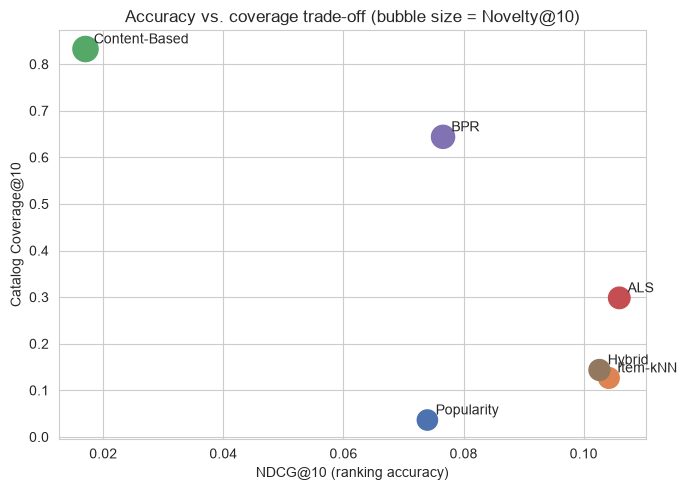

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = sns.color_palette("deep", n_colors=len(test_metrics))
sc = ax.scatter(test_metrics["NDCG@K"], test_metrics["Coverage@K"],
                 s=test_metrics["Novelty@K"] * 25, c=colors)
for name, row in test_metrics.iterrows():
    ax.annotate(name, (row["NDCG@K"], row["Coverage@K"]), xytext=(6, 4), textcoords="offset points")
ax.set_xlabel("NDCG@10 (ranking accuracy)")
ax.set_ylabel("Catalog Coverage@10")
ax.set_title("Accuracy vs. coverage trade-off (bubble size = Novelty@10)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/accuracy_vs_coverage_tradeoff.png", dpi=150)
plt.show()

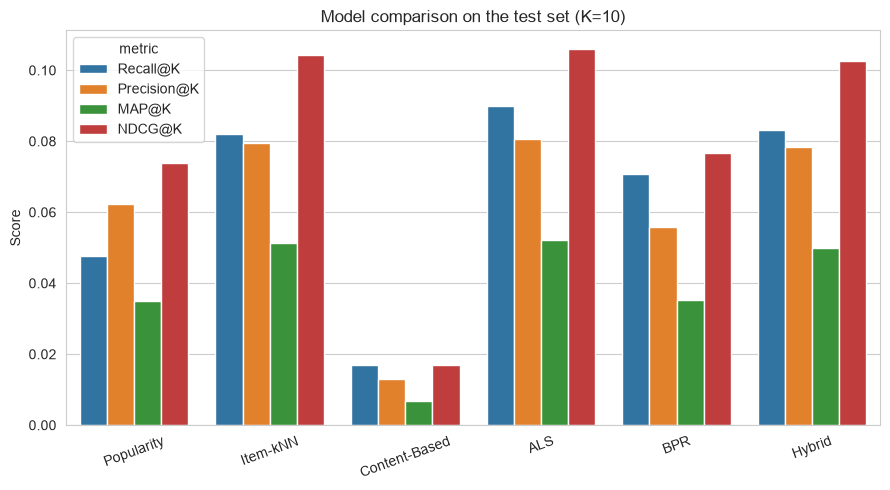

In [7]:
plot_df = test_metrics[main_cols].reset_index().melt(id_vars="model", var_name="metric", value_name="value")
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x="model", y="value", hue="metric")
plt.title("Model comparison on the test set (K=10)")
plt.ylabel("Score"); plt.xlabel("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/model_comparison.png", dpi=150)
plt.show()

## 4. Post-hoc diagnostics carried over from validation

The relevance-threshold sensitivity check (`rating >= 3` vs. `rating >= 4`)
and the interaction-representation ablation (all-interactions vs.
positive-only) were both run on **validation only**, in
`02_evaluation_setup.ipynb` Sections 6 and 4.7 respectively, specifically so
that neither could be influenced by test. Their conclusions (the model
ranking is stable under both relevance thresholds; Item-kNN keeps the
all-interactions representation while ALS/BPR switch to positive-only) are
applied here as already-decided inputs, not re-derived against test.